<a href="https://colab.research.google.com/github/Tilakrajrawat/ml_experiments/blob/main/experiment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Normal Equation
MSE: 0.5444842121526293
R2 : 0.6009790143573635

Gradient Descent
MSE: 0.5498529299768293
R2 : 0.5970445915953515

Scikit-learn Linear Regression
MSE: 0.5444842122132855
R2 : 0.600979014312912

Ridge Regression
MSE: 0.5444773522078508
R2 : 0.6009840416141063

Lasso Regression
MSE: 0.5495195333814075
R2 : 0.5972889186761847

Model Comparison
Normal Equation      MSE = 0.5445, R2 = 0.6010
Gradient Descent     MSE = 0.5499, R2 = 0.5970
Linear Regression    MSE = 0.5445, R2 = 0.6010
Ridge                MSE = 0.5445, R2 = 0.6010
Lasso                MSE = 0.5495, R2 = 0.5973


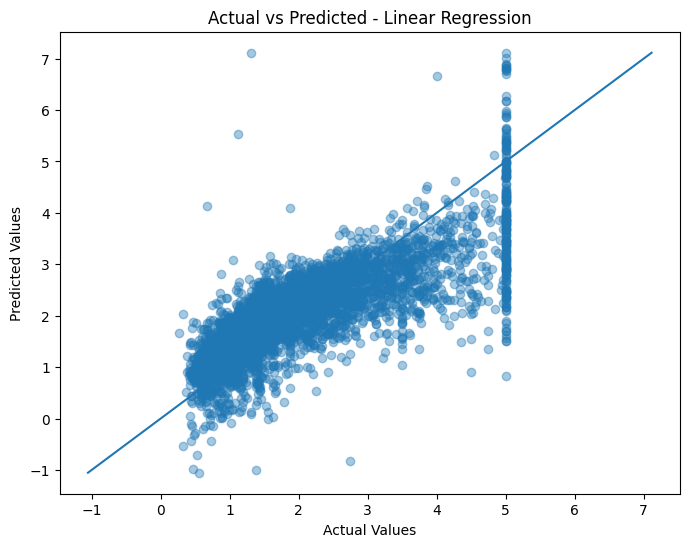

In [1]:
# Experiment 1: Linear Regression and Regularisation
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

data = fetch_california_housing()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

# Standardization is useful especially for Gradient Descent,
# Ridge and Lasso.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------
# 2. Linear Regression using Normal Equation
# --------------------------------------------------

# Add column of 1s for intercept
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# theta = (X^T X)^-1 X^T y
theta = np.linalg.pinv(X_train_bias.T @ X_train_bias) @ \
        X_train_bias.T @ y_train

y_pred_normal = X_test_bias @ theta

print("Normal Equation")
print("MSE:", mean_squared_error(y_test, y_pred_normal))
print("R2 :", r2_score(y_test, y_pred_normal))


# --------------------------------------------------
# 3. Linear Regression using Gradient Descent
# --------------------------------------------------

X_gd = X_train_scaled
X_test_gd = X_test_scaled

# Add bias
X_gd = np.c_[np.ones(X_gd.shape[0]), X_gd]
X_test_gd = np.c_[np.ones(X_test_gd.shape[0]), X_test_gd]

theta_gd = np.zeros(X_gd.shape[1])

learning_rate = 0.01
epochs = 1000
m = len(y_train)

for i in range(epochs):

    predictions = X_gd @ theta_gd

    error = predictions - y_train

    gradient = (2 / m) * X_gd.T @ error

    theta_gd -= learning_rate * gradient

y_pred_gd = X_test_gd @ theta_gd

print("\nGradient Descent")
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 :", r2_score(y_test, y_pred_gd))


# --------------------------------------------------
# 4. Scikit-learn Linear Regression
# --------------------------------------------------

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nScikit-learn Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 :", r2_score(y_test, y_pred_lr))


# --------------------------------------------------
# 5. Ridge Regression
# --------------------------------------------------

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("\nRidge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 :", r2_score(y_test, y_pred_ridge))


# --------------------------------------------------
# 6. Lasso Regression
# --------------------------------------------------

lasso = Lasso(alpha=0.01, max_iter=10000)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("\nLasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 :", r2_score(y_test, y_pred_lasso))


# --------------------------------------------------
# 7. Comparison
# --------------------------------------------------

models = {
    "Normal Equation": y_pred_normal,
    "Gradient Descent": y_pred_gd,
    "Linear Regression": y_pred_lr,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso
}

print("\nModel Comparison")

for name, predictions in models.items():
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"{name:20} MSE = {mse:.4f}, R2 = {r2:.4f}")


# --------------------------------------------------
# 8. Actual vs Predicted Plot
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.4)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Linear Regression")

# Perfect prediction line
minimum = min(y_test.min(), y_pred_lr.min())
maximum = max(y_test.max(), y_pred_lr.max())

plt.plot([minimum, maximum],
         [minimum, maximum])

plt.show()